# Analyse descriptive des données d'échecs

Dans cette partie, nous allons réaliser une analyse descriptive des données disponibles sur les joueurs et les parties d’échecs.

Les données utilisées sont :
- une table contenant les informations des joueurs (rating, niveau, activité)
- un fichier de parties d’échecs (stat_parties.parquet)

Nous allons étudier les principales tendances et relations entre les variables.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement des données 

In [17]:
#Chargement des joueurs
df_joueurs = pd.read_csv("../data/players_mars_2026.csv")
#Chargement des parties
df_parties = pd.read_parquet("../data/stat_parties.parquet")

# Analyse du rating des joueurs

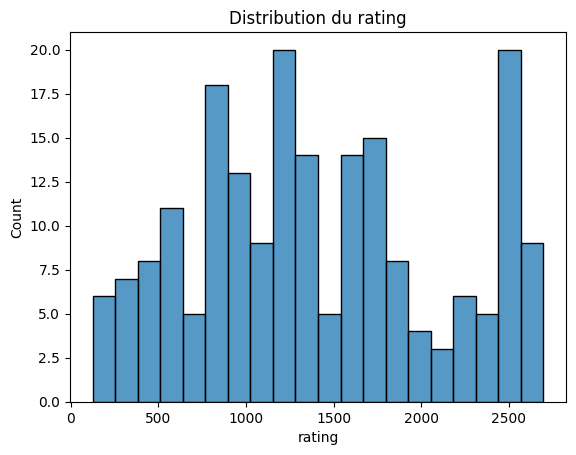

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df_joueurs['rating'], bins=20)
plt.title("Distribution du rating")
plt.show()

# Interpretation
On observe la distribution des ratings des joueurs.  
La majorité des joueurs se situe dans la plage {1000;2000}, ce qui permet de comprendre la structure globale du dataset.

# Analyse de l’activité des joueurs

Nous analysons ici la distribution du nombre de parties jouées afin d’identifier les profils de joueurs : occasionnels, réguliers et très actifs.

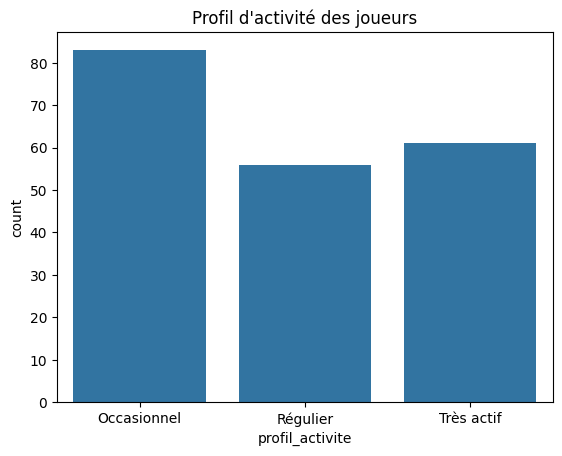

In [5]:
def categoriser_joueur(nb):
    if nb < 50:
        return "Occasionnel"
    elif nb < 100:
        return "Régulier"
    else:
        return "Très actif"

df_joueurs['profil_activite'] = df_joueurs['nb_games'].apply(categoriser_joueur)
sns.countplot(x='profil_activite', data=df_joueurs, order=["Occasionnel", "Régulier", "Très actif"])
plt.title("Profil d'activité des joueurs")
plt.show()

# On va ainsi croiser les deux activité et niveau

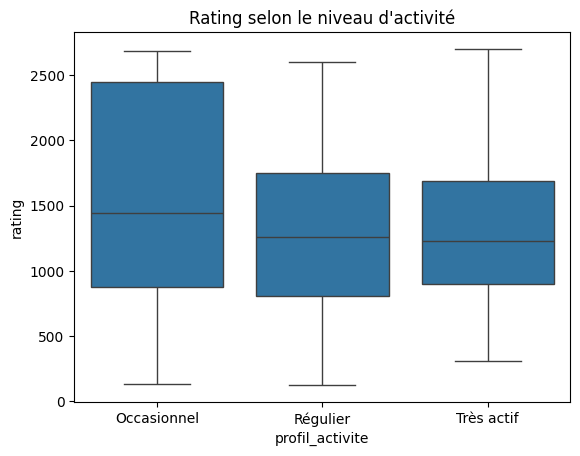

In [6]:
df_joueurs.groupby('profil_activite')['rating'].mean()
sns.boxplot(x='profil_activite', y='rating', data=df_joueurs,
            order=["Occasionnel", "Régulier", "Très actif"])
plt.title("Rating selon le niveau d'activité")
plt.show()

# Interpretation 
On observe que les joueurs peuvent être regroupés en trois profils d’activité : occasionnels, réguliers et très actifs.

L’analyse du rating selon ces profils permet d’étudier si l’expérience de jeu est liée au niveau des joueurs.

# Analyse du style de jeu des joueurs

Nous analysons ici le temps moyen de réflexion lors des premiers coups afin d’étudier le style de jeu des joueurs (rapide ou réfléchi).

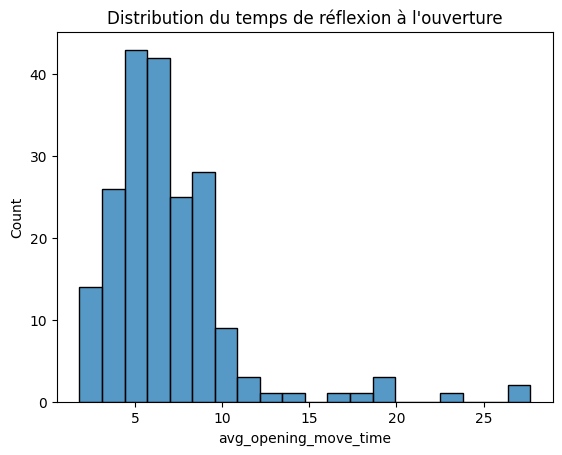

In [8]:
df_parties['avg_opening_move_time'].describe()
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df_parties['avg_opening_move_time'], bins=20)
plt.title("Distribution du temps de réflexion à l'ouverture")
plt.show()

# On va ainsi faire la relation avec le niveau des joueurs

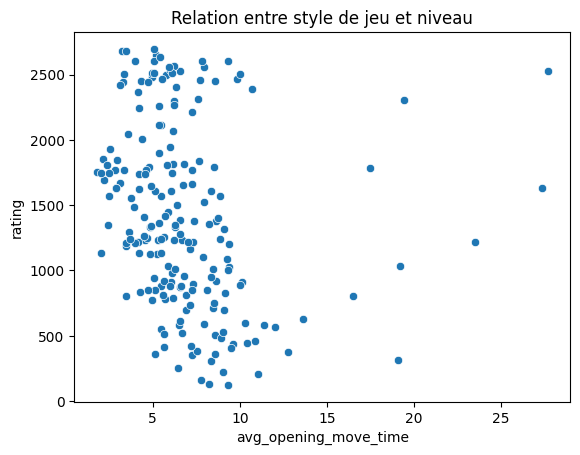

In [9]:
sns.scatterplot(
    x='avg_opening_move_time',
    y='rating',
    data=df_parties
)
plt.title("Relation entre style de jeu et niveau")
plt.show()

# Construction de profils de joueurs

Nous construisons des profils de joueurs à partir de plusieurs variables afin d’identifier différents styles de jeu.

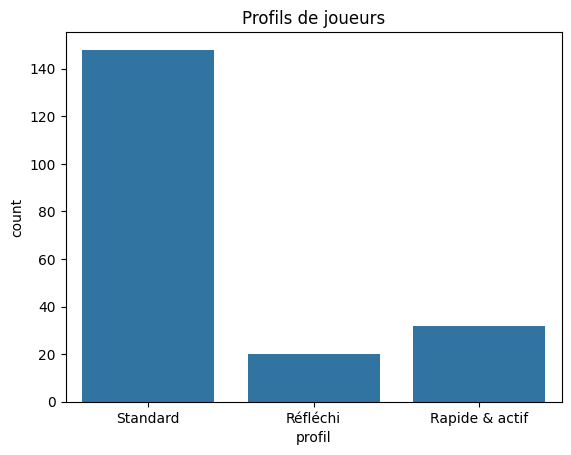

In [10]:
def profil_joueur(row):
    if row['avg_opening_move_time'] < 5 and row['nb_rapid_games'] > 50:
        return "Rapide & actif"
    elif row['avg_opening_move_time'] > 10:
        return "Réfléchi"
    else:
        return "Standard"

df_parties['profil'] = df_parties.apply(profil_joueur, axis=1)
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='profil', data=df_parties)
plt.title("Profils de joueurs")
plt.show()

# Relation entre vitesse de jeu et niveau

Nous étudions si le niveau des joueurs influence leur vitesse de jeu.

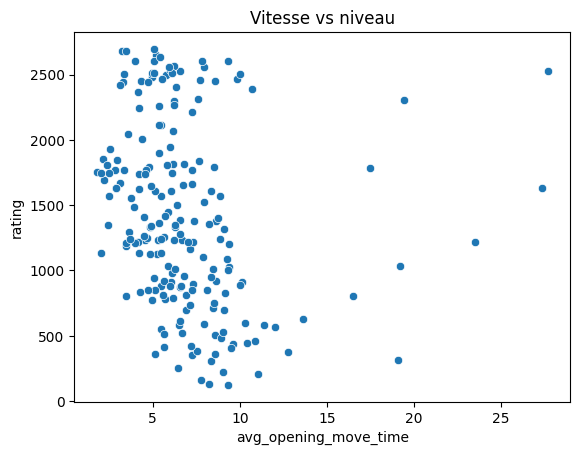

In [19]:
df_clean = df_parties.dropna(subset=['avg_opening_move_time', 'rating'])
df_clean['avg_opening_move_time'] = pd.to_numeric(df_clean['avg_opening_move_time'], errors='coerce')
df_clean['rating'] = pd.to_numeric(df_clean['rating'], errors='coerce')

df_clean = df_clean.dropna()
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    x='avg_opening_move_time',
    y='rating',
    data=df_clean
)

plt.title("Vitesse vs niveau")
plt.show()